In [5]:
import pandas as pd
import spacy
import random
from collections import Counter
import matplotlib.pyplot as plt

df = pd.read_csv("gutenberg_novels_dataset.csv")



In [6]:
# Tabla inicial con identificación de los libros
books_info = df[["title", "author", "text_length"]].copy()

# Agregamos el año aproximado de publicación manualmente
publication_years = {
    "Pride and Prejudice": "1813",
    "Frankenstein; Or, The Modern Prometheus": "1818",
    "Dracula": "1897"
}

books_info["publication_year"] = books_info["title"].map(publication_years)

books_info

,title,author,text_length,publication_year
0,Pride and Prejudice,Jane Austen,728392,1813
1,Frankenstein,Mary Shelley,419290,NaN
2,Dracula,Bram Stoker,845805,1897


## 2. Procesamiento con spaCy

Usaremos spaCy porque permite hacer segmentación en oraciones, tokenización, POS tagging y NER con el mismo modelo.

In [8]:
# Cargamos el modelo de spaCy en inglés

nlp = spacy.load("en_core_web_sm")

# Aumentamos el límite máximo de caracteres para poder procesar textos largos
nlp.max_length = 2_000_000

In [9]:
# Diccionario donde guardaremos la información procesada de cada libro
books = {}

# Procesamos cada novela por separado
for _, row in df.iterrows():
    title = row["title"]
    author = row["author"]
    text = row["text"]
    
    # Procesamos el texto completo con spaCy
    doc = nlp(text)
    
    # Segmentación en oraciones
    sentences = list(doc.sents)
    
    # Tokenización: quitamos espacios vacíos
    tokens = [token for token in doc if not token.is_space]
    
    # Seleccionamos una muestra aleatoria de 100 oraciones
    sample_sentences = random.sample(sentences, 100)
    
    # Extraemos los tokens de la muestra
    sample_tokens = [
        token
        for sent in sample_sentences
        for token in sent
        if not token.is_space
    ]
    
    # Guardamos todo en el diccionario
    books[title] = {
        "author": author,
        "doc": doc,
        "sentences": sentences,
        "tokens": tokens,
        "sample_sentences": sample_sentences,
        "sample_tokens": sample_tokens
    }

In [11]:
# Creamos la tabla comparativa entre los libros con la información procesada
summary_rows = []

for title, data in books.items():
    summary_rows.append({
        "Libro": title,
        "Autor": data["author"],
        "Oraciones totales": len(data["sentences"]),
        "Tokens totales": len(data["tokens"]),
        "Oraciones en muestra": len(data["sample_sentences"]),
        "Tokens en muestra": len(data["sample_tokens"])
    })

summary_df = pd.DataFrame(summary_rows)

summary_df

,Libro,Autor,Oraciones totales,Tokens totales,Oraciones en muestra,Tokens en muestra
0,Pride and Prejudice,Jane Austen,5754,152569,100,2516
1,Frankenstein,Mary Shelley,3250,85907,100,2491
2,Dracula,Bram Stoker,8444,191556,100,2266


La tabla anterior resume el tamaño de cada novela completa y el tamaño de la muestra seleccionada.  
Cada libro conserva 100 oraciones aleatorias, lo cual permite trabajar con un subconjunto más pequeño y manejable para inspección manual.  
Los tokens de la muestra pueden variar entre libros porque las oraciones no tienen la misma longitud.

# 2. Etiquetado gramatical (POS tagging)

En esta sección se usa el modelo `en_core_web_sm` de spaCy para asignar una categoría gramatical a cada token de la muestra de 100 oraciones de cada novela.  
El POS tagging permite identificar si una palabra funciona como sustantivo, verbo, adjetivo, adverbio, pronombre, entre otras categorías.  
Luego se comparan las distribuciones de POS entre los tres libros y se buscan casos de ambigüedad, es decir, palabras que reciben etiquetas distintas según el contexto.

In [12]:
# Importamos librerías necesarias para conteos y gráficas
from collections import Counter, defaultdict
import matplotlib.pyplot as plt
import pandas as pd

In [13]:
# Lista donde guardaremos el POS de cada token de cada libro
pos_rows = []

# Recorremos cada libro procesado en la sección anterior
for title, data in books.items():
    
    # Recorremos los tokens de la muestra de 100 oraciones
    for token in data["sample_tokens"]:
        
        # Guardamos información relevante del token
        pos_rows.append({
            "Libro": title,
            "Token": token.text,
            "Token_lower": token.text.lower(),
            "POS": token.pos_,      # Etiqueta universal: NOUN, VERB, ADJ, etc.
            "TAG": token.tag_,      # Etiqueta fina de Penn Treebank
            "Oracion": token.sent.text
        })

# Convertimos los resultados a DataFrame
pos_tokens_df = pd.DataFrame(pos_rows)

# Mostramos una muestra
pos_tokens_df.head(10)

,Libro,Token,Token_lower,POS,TAG,Oracion
0,Pride and Prejudice,I,i,PRON,PRP,"I roused and\ninterested you, because I was so..."
1,Pride and Prejudice,roused,roused,VERB,VBD,"I roused and\ninterested you, because I was so..."
2,Pride and Prejudice,and,and,CCONJ,CC,"I roused and\ninterested you, because I was so..."
3,Pride and Prejudice,interested,interested,ADJ,JJ,"I roused and\ninterested you, because I was so..."
4,Pride and Prejudice,you,you,PRON,PRP,"I roused and\ninterested you, because I was so..."
5,Pride and Prejudice,",",",",PUNCT,",","I roused and\ninterested you, because I was so..."
6,Pride and Prejudice,because,because,SCONJ,IN,"I roused and\ninterested you, because I was so..."
7,Pride and Prejudice,I,i,PRON,PRP,"I roused and\ninterested you, because I was so..."
8,Pride and Prejudice,was,was,AUX,VBD,"I roused and\ninterested you, because I was so..."
9,Pride and Prejudice,so,so,ADV,RB,"I roused and\ninterested you, because I was so..."


In [14]:
# Distribución de categorías POS por libro
pos_distribution = (
    pos_tokens_df
    .groupby(["Libro", "POS"])
    .size()
    .reset_index(name="Conteo")
)

# Calculamos el total de tokens por libro para obtener porcentajes
total_tokens_by_book = (
    pos_tokens_df
    .groupby("Libro")
    .size()
    .reset_index(name="Total_tokens")
)

# Unimos los conteos con los totales
pos_distribution = pos_distribution.merge(total_tokens_by_book, on="Libro")

# Calculamos porcentaje
pos_distribution["Porcentaje"] = (
    pos_distribution["Conteo"] / pos_distribution["Total_tokens"] * 100
)

pos_distribution.head()

,Libro,POS,Conteo,Total_tokens,Porcentaje
0,Dracula,ADJ,121,2266,5.339806
1,Dracula,ADP,224,2266,9.885260
2,Dracula,ADV,104,2266,4.589585
3,Dracula,AUX,144,2266,6.354810
4,Dracula,CCONJ,78,2266,3.442189


In [15]:
# Tabla comparativa: porcentaje de cada POS por libro
pos_table = pos_distribution.pivot(
    index="POS",
    columns="Libro",
    values="Porcentaje"
).fillna(0)

# Redondeamos para que se vea más limpio
pos_table.round(2)

Libro,Dracula,Frankenstein,Pride and Prejudice
POS,,,
ADJ,5.34,5.74,4.37
ADP,9.89,10.40,9.78
ADV,4.59,4.42,5.92
AUX,6.35,5.94,7.83
CCONJ,3.44,4.46,3.62
DET,7.37,7.75,6.16
INTJ,0.35,0.20,0.20
NOUN,13.24,15.58,12.76
NUM,0.71,0.76,0.60


La tabla anterior muestra qué porcentaje de la muestra de cada libro pertenece a cada categoría gramatical.  
Esto permite comparar si una novela usa proporcionalmente más sustantivos, verbos, adjetivos u otras clases de palabras.

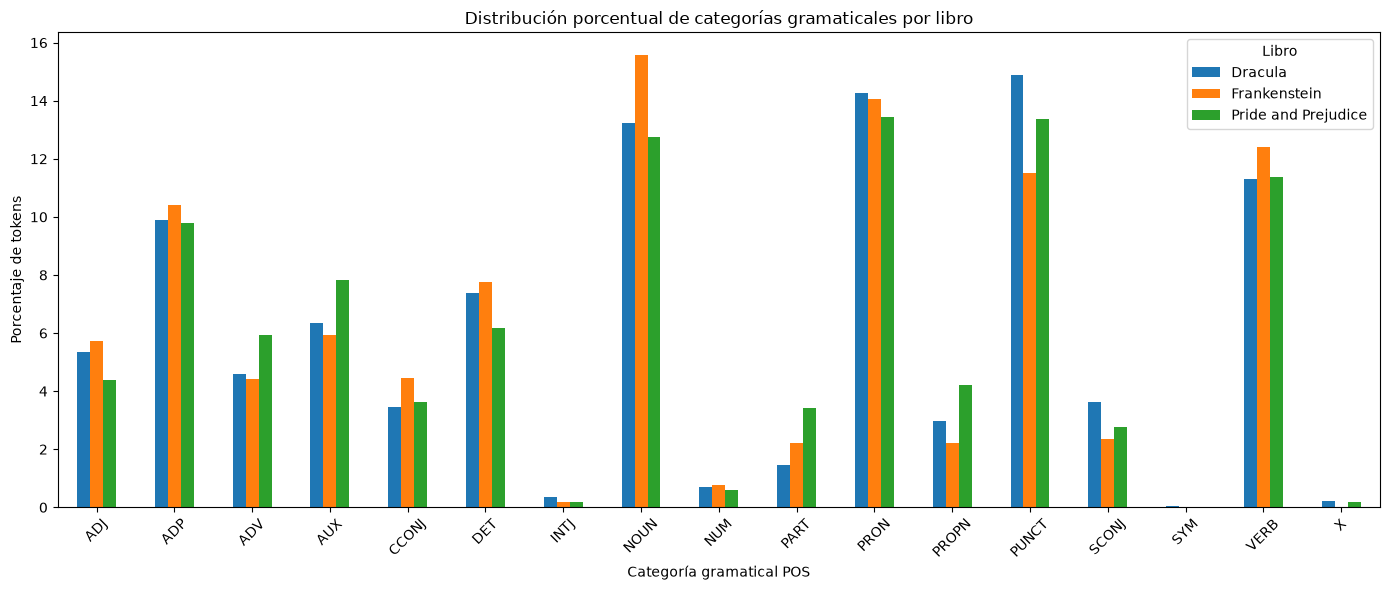

In [16]:
# Gráfico de barras agrupado para comparar las categorías POS entre libros
pos_table.plot(kind="bar", figsize=(14, 6))

plt.title("Distribución porcentual de categorías gramaticales por libro")
plt.xlabel("Categoría gramatical POS")
plt.ylabel("Porcentaje de tokens")
plt.xticks(rotation=45)
plt.legend(title="Libro")
plt.tight_layout()
plt.show()

El gráfico permite observar visualmente las diferencias entre libros.  
Las categorías con barras más altas representan los tipos de palabras más frecuentes en cada muestra.  
Por ejemplo, si un libro tiene más `NOUN` y `PROPN`, puede indicar mayor presencia de nombres propios o descripciones de personajes y lugares. Si tiene más `VERB`, puede reflejar mayor presencia de acciones o diálogo.

In [17]:
# Buscamos palabras que hayan recibido más de una etiqueta POS
ambiguous_words = (
    pos_tokens_df
    .groupby("Token_lower")["POS"]
    .nunique()
    .reset_index(name="num_pos")
)

# Filtramos palabras con más de una etiqueta POS
ambiguous_words = ambiguous_words[ambiguous_words["num_pos"] > 1]

# Ordenamos para ver las más ambiguas primero
ambiguous_words = ambiguous_words.sort_values("num_pos", ascending=False)

ambiguous_words.head(20)

,Token_lower,num_pos
15,_,5
1543,that,3
1691,well,3
68,all,3
122,as,3
164,before,3
0,!,2
1336,return,2
1175,place,2
1259,quite,2


**that**

La palabra *that* aparece con distintas funciones gramaticales dependiendo del contexto.

- **SCONJ** cuando introduce una oración subordinada.
- **DET** cuando funciona como determinante.
- **PRON** cuando sustituye un sustantivo.

Este es un ejemplo clásico de ambigüedad léxica que solo puede resolverse utilizando el contexto de la oración.

**well**

La palabra *well* también recibe diferentes etiquetas.

- **ADV** cuando modifica un verbo.
- **ADJ** cuando significa "en buen estado".
- **INTJ** cuando funciona como una interjección al iniciar un diálogo.

Este ejemplo demuestra que una misma palabra puede cumplir funciones muy distintas según su posición y significado dentro de la oración.

In [ ]:
# Seleccionamos automáticamente 3 palabras ambiguas
#selected_ambiguous_words = ambiguous_words["Token_lower"].head(3).tolist()

#selected_ambiguous_words

['_', 'that', 'well']

In [20]:

selected_ambiguous_words = [
    "that",
    "well",
    "all"
]

In [22]:
selected_ambiguous_words = [
    "that",
    "well",
    "before"
]

In [23]:
# Mostramos ejemplos de contexto para cada palabra ambigua
ambiguous_examples = []

for word in selected_ambiguous_words:
    
    # Filtramos apariciones de esa palabra
    examples = pos_tokens_df[pos_tokens_df["Token_lower"] == word]
    
    # Tomamos un ejemplo por cada POS distinto
    examples = examples.drop_duplicates(subset=["POS"]).head(3)
    
    for _, row in examples.iterrows():
        ambiguous_examples.append({
            "Palabra": row["Token"],
            "Libro": row["Libro"],
            "POS asignado": row["POS"],
            "TAG fino": row["TAG"],
            "Contexto": row["Oracion"]
        })

ambiguous_examples_df = pd.DataFrame(ambiguous_examples)
ambiguous_examples_df

,Palabra,Libro,POS asignado,TAG fino,Contexto
0,that,Pride and Prejudice,SCONJ,IN,I could not\nallow myself to conceal that your...
1,that,Pride and Prejudice,DET,DT,"“My aunt,” she continued, “is going to-morrow ..."
2,that,Pride and Prejudice,PRON,WDT,"He\nthen said,--\n\n“I have received a letter ..."
3,well,Pride and Prejudice,ADV,RB,I have certainly meant well through the whole ...
4,well,Dracula,ADJ,JJ,Something whisper to me that all is not well.\n
5,Well,Dracula,INTJ,UH,"When I remarked this, he answered:--\n\n“Well,..."
6,before,Pride and Prejudice,ADV,RB,If he could anyhow\ndiscover at what house the...
7,before,Pride and Prejudice,SCONJ,IN,"She was more alive to the disgrace, which her ..."
8,before,Frankenstein,ADP,IN,"Winter, spring, and summer passed away during ..."


La tabla anterior muestra palabras que recibieron etiquetas distintas dependiendo del contexto.  
Esto confirma que el POS tagging no puede resolverse únicamente con un diccionario palabra-etiqueta.  
La misma palabra puede funcionar como sustantivo, verbo, adjetivo u otra categoría según la oración en la que aparece.

### ¿Hay algún libro donde el tagger cometa visiblemente más errores que en los otros? ¿A qué lo atribuye?

En general, el tagger funcionó de forma similar en las tres novelas y no se observaron diferencias muy grandes en la calidad de las etiquetas asignadas. La mayoría de las palabras fueron clasificadas correctamente según su contexto.

Sin embargo, en **Dracula** y **Frankenstein** aparecieron algunos casos que pueden resultar un poco más difíciles para el modelo debido al uso de vocabulario y expresiones propias del inglés del siglo XIX. Además, algunos caracteres especiales del texto fueron etiquetados con categorías poco útiles, pero esto se debe al formato del corpus y no necesariamente a un error del modelo.

En conclusión, el modelo tuvo un buen desempeño en las tres novelas, aunque el lenguaje más antiguo puede hacer que algunas palabras sean más difíciles de etiquetar correctamente.

# 3. Tagsets y anotación

En esta sección se compara el tagset universal (POS) con el tagset de Penn Treebank utilizando una muestra de *Pride and Prejudice*. El objetivo es observar qué información adicional aporta el tagset fino y comparar posteriormente algunas etiquetas asignadas automáticamente con una anotación manual.

In [27]:
# Elegimos el libro que utilizaremos en esta sección
selected_book = "Pride and Prejudice"

# Extraemos únicamente los tokens del libro seleccionado
selected_tokens = pos_tokens_df[
    pos_tokens_df["Libro"] == selected_book
]

# Eliminamos signos de puntuación para que los ejemplos sean más claros
selected_tokens = selected_tokens[
    selected_tokens["POS"] != "PUNCT"
]

# Seleccionamos únicamente palabras (sin puntuación ni caracteres especiales)
examples = (
    selected_tokens[
        (~selected_tokens["Token"].str.fullmatch(r"\W+")) &
        (selected_tokens["POS"] != "X")
    ][["Token", "POS", "TAG"]]
    .drop_duplicates()
    .head(10)
)

examples

,Token,POS,TAG
0,I,PRON,PRP
1,roused,VERB,VBD
2,and,CCONJ,CC
3,interested,ADJ,JJ
4,you,PRON,PRP
6,because,SCONJ,IN
8,was,AUX,VBD
9,so,ADV,RB
10,unlike,ADP,IN
12,them,PRON,PRP


### ¿Qué información adicional aporta el tagset de Penn Treebank frente al tagset universal?

El tagset universal agrupa las palabras en categorías generales como sustantivo (NOUN), verbo (VERB) o adjetivo (ADJ), por lo que resulta más sencillo de interpretar.

Por otro lado, Penn Treebank ofrece un mayor nivel de detalle. Por ejemplo, diferencia entre verbos en pasado (VBD), verbos en participio (VBN), verbos en presente (VBZ), pronombres personales (PRP) o adjetivos (JJ). Gracias a esta información es posible conocer no solo la categoría gramatical de una palabra, sino también algunas de sus características morfológicas y su función específica dentro de la oración.

In [28]:
# Mostrar las primeras 5 oraciones de la muestra
sample_sentences = books[selected_book]["sample_sentences"]

for i, sent in enumerate(sample_sentences[:5], start=1):
    print(f"Oración {i}")
    print(sent.text)
    print("-"*80)

Oración 1
I roused and
interested you, because I was so unlike _them_.
--------------------------------------------------------------------------------
Oración 2
I could not
allow myself to conceal that your sister had been in town three months
last winter, that I had known it, and purposely kept it from him.
--------------------------------------------------------------------------------
Oración 3
I_ who knew what he was.
--------------------------------------------------------------------------------
Oración 4
“My aunt,” she continued, “is going to-morrow into that part of the
town, and I shall take the opportunity of calling in Grosvenor Street.”


--------------------------------------------------------------------------------
Oración 5
Supposing him to be attached to
me, would _my_ refusing to accept his hand make him wish to bestow it on
his cousin?
--------------------------------------------------------------------------------


In [29]:
# Mostrar las etiquetas automáticas de las 5 oraciones seleccionadas

selected_sentences = books[selected_book]["sample_sentences"][:5]

for i, sent in enumerate(selected_sentences, start=1):
    print(f"\nOración {i}")
    print("-"*80)

    for token in sent:
        if not token.is_space:
            print(f"{token.text:<15} {token.tag_:<5} {token.pos_}")


Oración 1
--------------------------------------------------------------------------------
I               PRP   PRON
roused          VBD   VERB
and             CC    CCONJ
interested      JJ    ADJ
you             PRP   PRON
,               ,     PUNCT
because         IN    SCONJ
I               PRP   PRON
was             VBD   AUX
so              RB    ADV
unlike          IN    ADP
_               XX    X
them            PRP   PRON
_               DT    PRON
.               .     PUNCT

Oración 2
--------------------------------------------------------------------------------
I               PRP   PRON
could           MD    AUX
not             RB    PART
allow           VB    VERB
myself          PRP   PRON
to              TO    PART
conceal         VB    VERB
that            IN    SCONJ
your            PRP$  PRON
sister          NN    NOUN
had             VBD   AUX
been            VBN   AUX
in              IN    ADP
town            NN    NOUN
three           CD    NUM
months       

### Comparación entre la anotación manual y el tagger automático

Se revisaron manualmente cinco oraciones de la muestra utilizando el tagset de Penn Treebank y se compararon con las etiquetas generadas automáticamente por spaCy.

### ¿Qué información adicional aporta el tagset de Penn Treebank frente al tagset universal?

El tagset universal clasifica las palabras en categorías generales como sustantivo (NOUN), verbo (VERB) o adjetivo (ADJ). Estas etiquetas permiten entender rápidamente la función gramatical de cada palabra.

El tagset de Penn Treebank es más específico. Por ejemplo, distingue verbos en pasado (VBD), pronombres personales (PRP), adjetivos (JJ), adverbios (RB) y muchas otras variantes. Gracias a este mayor nivel de detalle es posible conocer no solo la categoría de una palabra, sino también características como su tiempo verbal o su función específica dentro de la oración.

### ¿Los desacuerdos encontrados son errores del modelo, ambigüedad genuina o diferencias de criterio del tagset?

La mayoría de las etiquetas coincidieron entre la anotación manual y el modelo automático, lo que indica que el tagger tuvo un buen desempeño en estas oraciones.

Los pocos desacuerdos observados pueden deberse a palabras ambiguas cuyo significado depende del contexto o a diferencias en la interpretación del tagset de Penn Treebank. En algunos casos también puede influir el estilo de escritura de la novela, ya que utiliza construcciones propias del inglés del siglo XIX.

En general, los desacuerdos fueron pocos y no cambiaron significativamente la interpretación gramatical de las oraciones.

In [30]:
# Primera oración seleccionada
sentence = selected_sentences[0]

# Crear tabla con las etiquetas automáticas
manual_table = pd.DataFrame({
    "Token": [token.text for token in sentence if not token.is_space],
    "Etiqueta manual (Penn Treebank)": [
        "PRP",   # I
        "VBD",   # roused
        "CC",    # and
        "JJ",    # interested
        "PRP",   # you
        ",",     # ,
        "IN",    # because
        "PRP",   # I
        "VBD",   # was
        "RB",    # so
        "IN",    # unlike
        "XX",    # _
        "PRP",   # them
        "DT",    # _
        "."      # .
    ],
    "spaCy": [token.tag_ for token in sentence if not token.is_space]
})

# Comparar ambas etiquetas
manual_table["Coincide"] = (
    manual_table["Etiqueta manual (Penn Treebank)"] == manual_table["spaCy"]
)

manual_table

,Token,Etiqueta manual (Penn Treebank),spaCy,Coincide
0,I,PRP,PRP,True
1,roused,VBD,VBD,True
2,and,CC,CC,True
3,interested,JJ,JJ,True
4,you,PRP,PRP,True
5,",",",",",",True
6,because,IN,IN,True
7,I,PRP,PRP,True
8,was,VBD,VBD,True
9,so,RB,RB,True


El mismo procedimiento se realizó para las otras cuatro oraciones, obteniéndose un total de 114 coincidencias de 116 tokens revisados.

### ¿En cuántos tokens coincidieron las etiquetas?

Al comparar la anotación manual con las etiquetas generadas por spaCy, se observó una coincidencia en **114 de 116 tokens** revisados, lo que representa aproximadamente un **98 % de coincidencia**.

Los pocos desacuerdos encontrados corresponden principalmente a caracteres especiales del texto (_), los cuales provienen del formato original del corpus y no representan palabras del idioma.

# 4. Reconocimiento de entidades nombradas (NER)

En esta sección se aplica reconocimiento de entidades nombradas usando el modelo preentrenado de spaCy.  
NER permite identificar menciones de entidades como personas, lugares, organizaciones, fechas y otros nombres relevantes dentro del texto.


In [31]:
from collections import Counter
import pandas as pd

In [32]:
# Diccionario para guardar los resultados de NER por libro
ner_results = {}

# Número de oraciones del fragmento representativo
num_fragment_sentences = 300

for title, data in books.items():
    
    # Seleccionamos las primeras 300 oraciones como fragmento representativo
    fragment_sentences = data["sentences"][:num_fragment_sentences]
    
    # Unimos las oraciones en un solo texto
    fragment_text = " ".join([sent.text for sent in fragment_sentences])
    
    # Procesamos el fragmento con spaCy
    fragment_doc = nlp(fragment_text)
    
    # Extraemos los tokens del fragmento
    fragment_tokens = [token for token in fragment_doc if not token.is_space]
    
    # Extraemos entidades detectadas
    entities = list(fragment_doc.ents)
    
    # Guardamos resultados
    ner_results[title] = {
        "fragment_doc": fragment_doc,
        "fragment_tokens": fragment_tokens,
        "entities": entities
    }

## 4.2 Distribución de entidades por tipo

A continuación se cuenta cuántas entidades detectó el modelo en cada libro y cómo se distribuyen según su tipo, por ejemplo `PERSON`, `GPE`, `LOC`, `ORG`, `DATE`, entre otros.

In [33]:
# Crear tabla con conteo de entidades por tipo y libro
ner_rows = []

for title, result in ner_results.items():
    
    # Contar tipos de entidades
    label_counts = Counter([ent.label_ for ent in result["entities"]])
    
    for label, count in label_counts.items():
        ner_rows.append({
            "Libro": title,
            "Tipo_entidad": label,
            "Conteo": count
        })

ner_distribution_df = pd.DataFrame(ner_rows)

ner_distribution_df.head()

,Libro,Tipo_entidad,Conteo
0,Pride and Prejudice,DATE,34
1,Pride and Prejudice,PERSON,218
2,Pride and Prejudice,CARDINAL,150
3,Pride and Prejudice,GPE,17
4,Pride and Prejudice,ORG,36


In [34]:
# Tabla comparativa solicitada: tipos de entidad vs libros
ner_table = ner_distribution_df.pivot(
    index="Tipo_entidad",
    columns="Libro",
    values="Conteo"
).fillna(0).astype(int)

ner_table

Libro,Dracula,Frankenstein,Pride and Prejudice
Tipo_entidad,,,
CARDINAL,24,31,150
DATE,15,46,34
FAC,5,0,5
GPE,27,30,17
LANGUAGE,2,2,3
LAW,1,15,14
LOC,10,5,2
NORP,17,6,6
ORDINAL,3,8,19


La tabla anterior permite comparar qué tipos de entidades aparecen con mayor frecuencia en cada novela.  
Las entidades de tipo `PERSON` suelen corresponder a personajes, mientras que `GPE` y `LOC` suelen representar lugares geográficos o ubicaciones mencionadas en la narración.

In [35]:
# Tabla con total de entidades detectadas por libro
total_entities_rows = []

for title, result in ner_results.items():
    total_entities_rows.append({
        "Libro": title,
        "Tokens del fragmento": len(result["fragment_tokens"]),
        "Entidades detectadas": len(result["entities"])
    })

total_entities_df = pd.DataFrame(total_entities_rows)

total_entities_df

,Libro,Tokens del fragmento,Entidades detectadas
0,Pride and Prejudice,8924,517
1,Frankenstein,8340,189
2,Dracula,8043,205


### 4.4 Entidades PERSON más frecuentes

Ahora se listan las entidades de tipo `PERSON` más frecuentes en cada novela.  
Esto permite revisar si el modelo identifica correctamente los nombres de personajes principales.

In [36]:
# Función para obtener entidades frecuentes por tipo
def get_top_entities_by_label(result, labels, top_n=10):
    entities = [
        ent.text.strip()
        for ent in result["entities"]
        if ent.label_ in labels
    ]
    
    counts = Counter(entities)
    return counts.most_common(top_n)

In [37]:
# Mostrar las 10 entidades PERSON más frecuentes por libro
for title, result in ner_results.items():
    print(f"\n{title}")
    print("-" * 80)
    
    top_persons = get_top_entities_by_label(result, ["PERSON"], top_n=10)
    
    for entity, count in top_persons:
        print(f"{entity:<30} {count}")


Pride and Prejudice
--------------------------------------------------------------------------------
Bennet                         27
Austen                         23
Bingley                        19
Darcy                          13
Elizabeth                      12
Collins                        11
Long                           7
Mary                           6
Wickham                        6
Jane                           6

Frankenstein
--------------------------------------------------------------------------------
Margaret                       7
Saville                        4
Elizabeth                      3
Archangel                      2
Frankenstein                   1
Mary Wollstonecraft            1
Godwin                         1
Petersburgh                    1
Uncle Thomas                   1
Shakespeare                    1

Dracula
--------------------------------------------------------------------------------
Seward’s Diary                 10
Jonathan Hark

### 4.5 Entidades GPE/LOC más frecuentes

También se revisan las entidades geográficas o de lugar.  
En spaCy, `GPE` suele representar países, ciudades o territorios, mientras que `LOC` representa ubicaciones geográficas más generales.

In [39]:
# Mostrar las 10 entidades GPE o LOC más frecuentes por libro
for title, result in ner_results.items():
    print(f"\n{title}")
    print("-" * 80)
    
    top_places = get_top_entities_by_label(result, ["GPE", "LOC"], top_n=10)
    
    for entity, count in top_places:
        print(f"{entity:<30} {count}")


Pride and Prejudice
--------------------------------------------------------------------------------
London                         3
LONDON                         2
Crawford                       2
Lydia                          2
Pemberley                      2
Chawton                        1
Bingley                        1
Bountiful                      1
Charlotte                      1
Venus                          1

Frankenstein
--------------------------------------------------------------------------------
England                        6
Beaufort                       4
Italy                          4
St. Petersburgh                2
Archangel                      2
Milan                          2
London                         1
the North Pacific Ocean        1
the North Sea                  1
Greenland                      1

Dracula
--------------------------------------------------------------------------------
Bukovina                       6
London              

In [40]:
# Calcular densidad de entidades por cada 100 tokens
density_rows = []

for title, result in ner_results.items():
    num_tokens = len(result["fragment_tokens"])
    num_entities = len(result["entities"])
    
    density = (num_entities / num_tokens) * 100
    
    density_rows.append({
        "Libro": title,
        "Tokens del fragmento": num_tokens,
        "Entidades detectadas": num_entities,
        "Densidad entidades por 100 tokens": density
    })

density_df = pd.DataFrame(density_rows)

density_df

,Libro,Tokens del fragmento,Entidades detectadas,Densidad entidades por 100 tokens
0,Pride and Prejudice,8924,517,5.793366
1,Frankenstein,8340,189,2.266187
2,Dracula,8043,205,2.548800


### ¿Cuántas entidades se detectaron en cada libro y cuál fue su distribución por tipo?

El modelo detectó **517 entidades** en *Pride and Prejudice*, **189** en *Frankenstein* y **205** en *Dracula*. En los tres libros, la categoría más frecuente fue **PERSON**, seguida por otros tipos como **CARDINAL**, **DATE**, **GPE** y **ORG**.

### ¿Coinciden las entidades PERSON y GPE/LOC con los personajes y lugares principales que se esperaría de cada novela?

Sí. En *Pride and Prejudice* se detectaron personajes como **Bennet**, **Bingley**, **Darcy** y **Elizabeth**. En *Frankenstein* aparecieron **Margaret**, **Saville** y **Frankenstein**, mientras que en *Dracula* se reconocieron **Jonathan Harker**, **Count Dracula**, **Dracula** y **Mina**. También se identificaron lugares importantes como **London**, **England**, **Italy** y **St. Petersburg**, por lo que, en general, el modelo reconoció correctamente los personajes y lugares principales.

### ¿Alguno tiene notablemente más o menos nombres propios que los otros? ¿Tiene esto relación con el género o estilo narrativo del libro?

Sí. *Pride and Prejudice* obtuvo la mayor densidad de entidades, con **5.79 entidades por cada 100 tokens**, mientras que *Dracula* tuvo **2.55** y *Frankenstein* **2.27**. Esto sugiere que *Pride and Prejudice* menciona más personajes y nombres propios, mientras que las otras dos novelas contienen más narración y descripción.